<h2>Reading and Writing Data using Rasterio</h2>


Red band
(1, 10980, 10980)
uint16
[[[ 793  832  899 ... 1190 1221 1250]
  [ 759  803  813 ... 1223 1223 1242]
  [ 728  834  826 ... 1262 1251 1252]
  ...
  [2351 2424 2522 ...    0    0    0]
  [2281 2372 2380 ...    0    0    0]
  [2130 2106 2088 ...    0    0    0]]]

Green band
(1, 10980, 10980)
uint16
[[[ 839  888  945 ... 1046 1070 1077]
  [ 842  874  878 ... 1063 1073 1074]
  [ 801  897  878 ... 1095 1079 1067]
  ...
  [1154 1172 1200 ...    0    0    0]
  [1128 1155 1158 ...    0    0    0]
  [1087 1072 1072 ...    0    0    0]]]

Blue band
(1, 10980, 10980)
uint16
[[[1032 1048 1107 ... 1071 1087 1109]
  [ 975 1048 1038 ... 1092 1112 1116]
  [ 978 1051 1048 ... 1140 1131 1112]
  ...
  [1017 1019 1029 ...    0    0    0]
  [1030 1036 1025 ...    0    0    0]
  [ 992  996  993 ...    0    0    0]]]
10.11888633415284


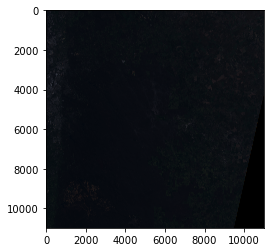

In [2]:
# Reading and writing data

import rasterio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

print("\nRed band")
with rasterio.open("./DATA_ESA/202009230226_S2B_MSI_ESA_50HMK_B04.jp2", "r") as input_file_r:
    img_r = input_file_r.read()   
print(img_r.shape)    
print(img_r.dtype)   
print(img_r)    

print("\nGreen band")
with rasterio.open("./DATA_ESA/202009230226_S2B_MSI_ESA_50HMK_B03.jp2", "r") as input_file_g:
    img_g = input_file_g.read()   
print(img_g.shape)    
print(img_g.dtype)  
print(img_g)    

print("\nBlue band")
with rasterio.open("./DATA_ESA/202009230226_S2B_MSI_ESA_50HMK_B02.jp2", "r") as input_file_b:
    img_b = input_file_b.read()   
print(img_b.shape)    
print(img_b.dtype)  
print(img_b)

# TODO - Scale data to uint8 

img_r_scaled = (255 / (np.max(img_r) - np.min(img_r)) * img_r).astype(np.uint8)
img_g_scaled = (255 / (np.max(img_g) - np.min(img_g)) * img_g).astype(np.uint8)
img_b_scaled = (255 / (np.max(img_b) - np.min(img_b)) * img_b).astype(np.uint8)

print(np.mean(img_r_scaled[0]))

rgb = np.dstack((img_r_scaled[0], img_g_scaled[0], img_b_scaled[0]))

# NOTE: Problem due to positively skewed data 
plt.imshow(rgb)

In [6]:
import rasterio

print("\nRead entire image into memory")
with rasterio.open("./DATA_ESA/202009230226_S2B_MSI_ESA_50HMK_B08.jp2") as input_file_nir:
    img_nir = input_file_nir.read(1)
  
    print("\nIMAGE SHAPE: " + str(img_nir.shape)    )
    print(img_nir) 

    print("\nImage extents")
    print(input_file_nir.bounds)  

    print("\nProfile")
    print(input_file_nir.profile)
    
    print("\nCoordinate reference system")
    print(input_file_nir.crs)
       


Read entire image into memory

IMAGE SHAPE: (10980, 10980)
[[1453 1628 1665 ... 2481 2459 2517]
 [1497 1611 1612 ... 2492 2503 2520]
 [1471 1586 1605 ... 2528 2527 2522]
 ...
 [2625 2677 2797 ...    0    0    0]
 [2509 2591 2655 ...    0    0    0]
 [2339 2294 2263 ...    0    0    0]]

Image extents
BoundingBox(left=399960.0, bottom=6390220.0, right=509760.0, top=6500020.0)

Profile
{'driver': 'JP2OpenJPEG', 'dtype': 'uint16', 'nodata': None, 'width': 10980, 'height': 10980, 'count': 1, 'crs': CRS.from_epsg(32750), 'transform': Affine(10.0, 0.0, 399960.0,
       0.0, -10.0, 6500020.0), 'blockxsize': 1024, 'blockysize': 1024, 'tiled': True}

Coordinate reference system
EPSG:32750


In [1]:
# Reading and writing windows

import rasterio
from rasterio.windows import Window

print("\nRead one tile at a time - start at top-left")
tile_width = 512
tile_height = 512

# Start at top-left tile
col_off = 0  # Top left
row_off = 0
w_1 = Window(col_off, row_off, tile_width, tile_height) # NOTE: col_off is first

with rasterio.open("DATA_ESA/202009230226_S2B_MSI_ESA_50HMK_B08.jp2", window=w_1) as input_file_nir:
    img_nir = input_file_nir.read(1, window=w_1)
        
print("\nTILE SHAPE: " + str(img_nir.shape)    )
print(img_nir) 

print("\nPixel coordinates")
print(w_1)

print("Geographic coordinates")
win_transform = input_file_nir.window_transform(w_1)
print(win_transform)

# NOTE: Default coordinate is at the centre of the pixel so need to the the "offset" option
print("\nWindow top-left")
print(rasterio.transform.xy(win_transform,0,0, offset='ul') )
print("Window bottom-right")
print(rasterio.transform.xy(win_transform,tile_width,tile_height, offset='ul') ) 
      

tile_width = 512
tile_height = 512
    
print("\nProgress to next tile on the right")
row_off = 0
col_off = tile_width
w_2 = Window(col_off , row_off, tile_width, tile_height)

with rasterio.open("DATA_ESA/202009230226_S2B_MSI_ESA_50HMK_B08.jp2", window=w_2) as input_file_nir:
    img_nir = input_file_nir.read(1, window=w_2)
    
print("\nTILE SHAPE: " + str(img_nir.shape)    )   
print(img_nir) 

print("\nPixel coordinates")
print(w_2)

print("Geographic coordinates")
win_transform = input_file_nir.window_transform(w_2) 
print(win_transform)

print("Window top-left")
print(rasterio.transform.xy(win_transform,0,0, offset='ul') ) 
print("Window bottom-right")
print(rasterio.transform.xy(win_transform,tile_width,tile_height, offset='ul') ) 

print("\nProcess  tile below top-left tile")
row_off = tile_height
col_off = 0
w_3 = Window(col_off, row_off, tile_width, tile_height)   
print(w_3)

print("Geographic coordinates")
win_transform = input_file_nir.window_transform(w_3) 
print(win_transform)

print("Window top-left")
print(rasterio.transform.xy(win_transform,0, 0, offset='ul') ) 
print("Window bottom-right")
print(rasterio.transform.xy(win_transform, tile_width, tile_height, offset='ul') ) 


'''
# Exercise - Process all tiles one by one in a loop
'''






Read entire image into memory

IMAGE SHAPE: (10980, 10980)
[[1453 1628 1665 ... 2481 2459 2517]
 [1497 1611 1612 ... 2492 2503 2520]
 [1471 1586 1605 ... 2528 2527 2522]
 ...
 [2625 2677 2797 ...    0    0    0]
 [2509 2591 2655 ...    0    0    0]
 [2339 2294 2263 ...    0    0    0]]

Image extents
BoundingBox(left=399960.0, bottom=6390220.0, right=509760.0, top=6500020.0)

Read one tile at a time - start at top-left

TILE SHAPE: (512, 512)
[[1453 1628 1665 ... 3291 3247 3443]
 [1497 1611 1612 ... 3115 2996 3366]
 [1471 1586 1605 ... 2962 2981 3269]
 ...
 [1810 2194 2274 ... 3312 2815 2640]
 [2125 2192 2240 ... 3537 3242 2644]
 [2167 2080 2148 ... 3569 3481 2796]]

Pixel coordinates
Window(col_off=0, row_off=0, width=512, height=512)
Geographic coordinates
| 10.00, 0.00, 399960.00|
| 0.00,-10.00, 6500020.00|
| 0.00, 0.00, 1.00|

Window top-left
(399960.0, 6500020.0)
Window bottom-right
(405080.0, 6494900.0)

Progress to next tile on the right

TILE SHAPE: (512, 512)
[[3583 3707 3740

'\n# Exercise - Process all tiles one by one in a loop\n'

In [11]:
# Resampling data - from https://rasterio.readthedocs.io/en/latest/topics/resampling.html

import rasterio
from rasterio.enums import Resampling

upscale_factor = 2

with rasterio.open("DATA_ESA/202009230226_S2B_MSI_ESA_50HMK_B08.jp2") as dataset:

    # resample data to target shape
    data = dataset.read(
        out_shape=(
            dataset.count,
            int(dataset.height * upscale_factor), # Shape of output buffer
            int(dataset.width * upscale_factor)
        ),
        resampling=Resampling.bilinear
    )

    print("\nOriginal transform")
    print(dataset.transform)
    
    # scale image transform
    transform = dataset.transform * dataset.transform.scale(
        (dataset.width / data.shape[-1]),
        (dataset.height / data.shape[-2])
    )
    
    print("\nResampled transform")
    print(transform)


Original transform
| 10.00, 0.00, 399960.00|
| 0.00,-10.00, 6500020.00|
| 0.00, 0.00, 1.00|

Resampled transform
| 5.00, 0.00, 399960.00|
| 0.00,-5.00, 6500020.00|
| 0.00, 0.00, 1.00|
